<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Assignment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
# Basic libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tarfile

# Image handling
from PIL import Image

# ML utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns



In [40]:

# DOWNLOAD THE FLOWER DATASET (PUBLIC, NO LOGIN REQUIRED)

url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
archive_name = "flower_photos.tgz"

# Download only if not already present
if not os.path.exists(archive_name):
    !wget {url}

# EXTRACT THE DATASET

if not os.path.exists("flower_photos"):
    with tarfile.open(archive_name, "r:gz") as tar:
        tar.extractall()

# Path to the dataset folder
image_folder = "flower_photos"
print("Image folder:", image_folder)
print("Classes found:", os.listdir(image_folder))


Image folder: flower_photos
Classes found: ['LICENSE.txt', 'daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [41]:
# IMAGE PREPROCESSING SETTINGS
IMG_SIZE = 64  # Resize all images to 64x64
X = []         # List to store image arrays
y = []         # List to store labels
class_names = []  # List of class names

# BUILD CLASS → INDEX MAPPING
for cls in sorted(os.listdir(image_folder)):
    cls_path = os.path.join(image_folder, cls)
    if os.path.isdir(cls_path):
        class_names.append(cls)

class_to_idx = {cls: i for i, cls in enumerate(class_names)}
print("Class mapping:", class_to_idx)

# LOAD, RESIZE, NORMALIZE IMAGES
for cls in class_names:
    cls_path = os.path.join(image_folder, cls)
    label = class_to_idx[cls]

    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)

        # Load image safely
        try:
            img = Image.open(fpath).convert("RGB")
        except:
            continue

        # Resize to uniform size
        img = img.resize((IMG_SIZE, IMG_SIZE))

        # Convert to array + normalize pixel values
        arr = np.array(img).astype("float32") / 255.0

        X.append(arr)
        y.append(label)

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)
print("Classes:", class_names)


Class mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
Dataset shape: (3670, 64, 64, 3) (3670,)
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [42]:
# FLATTEN IMAGES FOR CLASSICAL ML MODELS
n_samples, h, w, c = X.shape
X_flat = X.reshape(n_samples, -1)

# SPLIT INTO TRAIN AND TEST SETS
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2936, 12288)
Test shape: (734, 12288)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best RF parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Accuracy: 0.5177111716621253
Random Forest Precision: 0.5201609058503448
Random Forest Recall: 0.5177111716621253
Random Forest F1: 0.511943959396725

Classification Report:
               precision    recall  f1-score   support

       daisy       0.60      0.43      0.50       127
   dandelion       0.52      0.64      0.57       179
       roses       0.48      0.33      0.39       128
  sunflowers       0.56      0.64      0.60       140
      tulips       0.45      0.50      0.47       160

    accuracy                           0.52       734
   macro avg       0.52      0.51      0.51       734
weighted avg       0.52      0.52      0.51       734



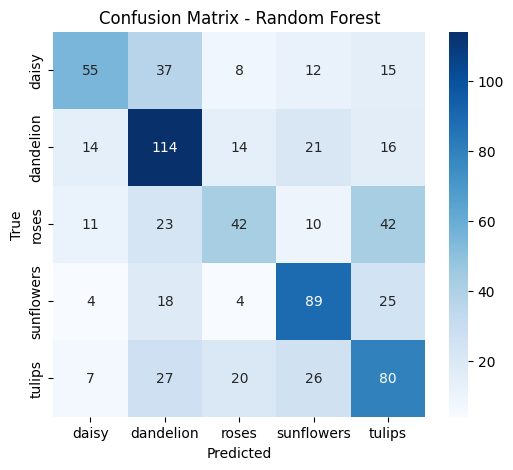

In [43]:
# DEFINE HYPERPARAMETER GRID FOR RANDOM FOREST
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ( accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
# GRID SEARCH FOR BEST PARAMETERS
grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)

# Extract best model
best_rf = grid_rf.best_estimator_

# MAKE PREDICTIONS
y_pred_rf = best_rf.predict(X_test)


# EVALUATE MODEL
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average="weighted"
)

print("Random Forest Accuracy:", acc_rf)
print("Random Forest Precision:", prec_rf)
print("Random Forest Recall:", rec_rf)
print("Random Forest F1:", f1_rf)

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf, target_names=class_names))


# CONFUSION MATRIX
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


SVM Accuracy: 0.5490463215258855
SVM Precision: 0.5505234948081267
SVM Recall: 0.5490463215258855
SVM F1: 0.5437568224475183

Classification Report:
               precision    recall  f1-score   support

       daisy       0.55      0.43      0.48       127
   dandelion       0.53      0.72      0.61       179
       roses       0.55      0.42      0.48       128
  sunflowers       0.63      0.63      0.63       140
      tulips       0.50      0.49      0.49       160

    accuracy                           0.55       734
   macro avg       0.55      0.54      0.54       734
weighted avg       0.55      0.55      0.54       734



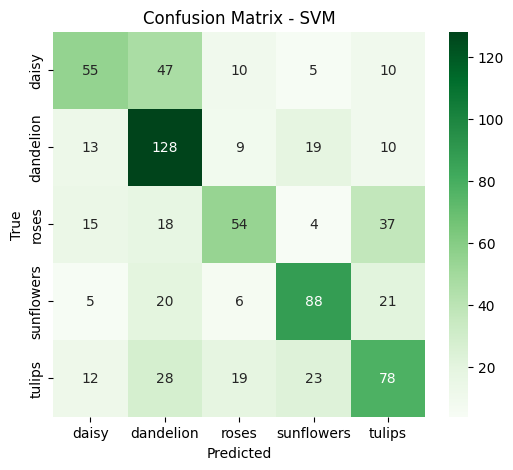

In [44]:
# TRAIN SVM MODEL (RBF KERNEL)
svm = SVC(kernel="rbf", C=1.0, gamma="scale")
svm.fit(X_train, y_train)

# PREDICT WITH SVM
y_pred_svm = svm.predict(X_test)

# EVALUATE SVM
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm, rec_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, average="weighted"
)

print("SVM Accuracy:", acc_svm)
print("SVM Precision:", prec_svm)
print("SVM Recall:", rec_svm)
print("SVM F1:", f1_svm)

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_svm, target_names=class_names))

# CONFUSION MATRIX
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names,
            cmap="Greens")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


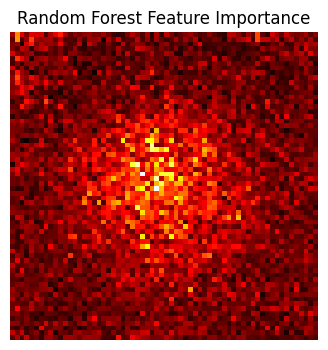

In [45]:
# FEATURE IMPORTANCE (AVERAGED OVER CHANNELS)

importances = best_rf.feature_importances_
importances_img = importances.reshape(h, w, c).mean(axis=2)

plt.figure(figsize=(4,4))
plt.imshow(importances_img, cmap="hot")
plt.title("Random Forest Feature Importance")
plt.axis("off")
plt.show()


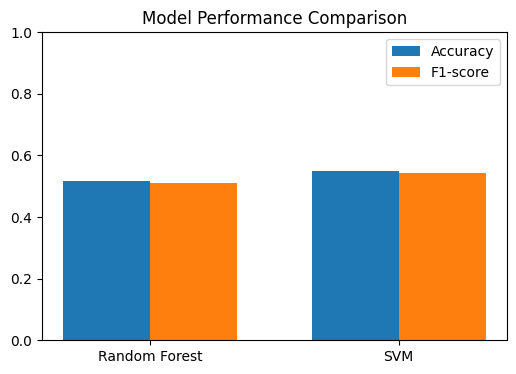

In [46]:
# COMPARE RF VS SVM PERFORMANCE
models = ["Random Forest", "SVM"]
accs = [acc_rf, acc_svm]
f1s = [f1_rf, f1_svm]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, accs, width, label="Accuracy")
plt.bar(x + width/2, f1s, width, label="F1-score")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()


In [47]:
# FUNCTION TO PREPROCESS AND PREDICT NEW IMAGES
def preprocess_image(path, img_size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize((img_size, img_size))
    arr = np.array(img).astype("float32") / 255.0
    arr_flat = arr.reshape(1, -1)
    return arr_flat

def predict_image(path, model=best_rf):
    arr_flat = preprocess_image(path)
    pred = model.predict(arr_flat)[0]
    print("Predicted class:", class_names[pred])

# Example:
# predict_image("/content/my_flower.jpg")
